In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import pandas as pd
sentiment =  pd.read_csv('/content/gdrive/MyDrive/english_data/eng_entity_sentiments_with_date.csv') # gives us sentiment
data_with_news_source = pd.read_csv('/content/gdrive/MyDrive/RUWA_new.csv', usecols=['Site']) # gives us news sources for each document
events = pd.read_csv('/content/gdrive/MyDrive/english_data/extracted_event.csv')

In [ ]:
data_with_news_source['id'] = range(1, len(data_with_news_source)+1)

In [ ]:
sentiment = pd.merge(sentiment, data_with_news_source, on='id', how='left')

In [ ]:
sentiment.head()


,Unnamed: 0,id_x,chunk_index,entity,entity_type,overall_sentiment,mixed_sentiment_score,negative_sentiment_score,neutral_sentiment_score,positive_sentiment_score,order,id,date,Site
0,0,3,1,"1,1",QUANTITY,NEUTRAL,0.000003,0.000004,0.999990,0.000003,1,1,02/28/2022,bbc.co.uk
1,1,4,1,Ukraine Ukraine Ukraine,LOCATION,NEUTRAL,0.000000,0.000005,0.999995,0.000000,1,1,02/28/2022,bbc.co.uk
2,2,5,1,FebruarySharecloseShare,DATE,NEUTRAL,0.000000,0.000001,0.999999,0.000000,1,1,02/28/2022,bbc.co.uk
3,3,6,1,pageCopy,OTHER,NEUTRAL,0.000000,0.000000,1.000000,0.000000,1,1,02/28/2022,bbc.co.uk
4,4,7,1,linkAbout,OTHER,NEUTRAL,0.000000,0.000000,1.000000,0.000000,1,1,02/28/2022,bbc.co.uk


In [ ]:
# --- Google Colab Time Series Multi-Series Analysis Utility ---
# If statsmodels is missing in your runtime, uncomment the next line:
# !pip -q install statsmodels

from typing import Callable, List, Optional, Sequence, Tuple, Union, Dict
import textwrap
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


def build_timeseries_df(
    timestamps_list: List[List],
    values_list: List[List[float]],
    labels: List[str],
    *,
    resample_rule: Optional[str] = None,
    interpolation: Optional[str] = "time"
) -> pd.DataFrame:
    """
    Build a single time-indexed DataFrame from multiple series.

    Parameters
    ----------
    timestamps_list : List[List]
        A list where each element is a list of timestamps (str/np.datetime64/datetime).
        Example: [[t1, t2, ...], [t1', t2', ...], ...]
    values_list : List[List[float]]
        A list where each element is a list of numeric values aligned to the corresponding timestamps list.
    labels : List[str]
        Series names (one per series).
    resample_rule : Optional[str]
        Pandas offset alias to resample to (e.g. 'D', 'H', '15min', 'MS').
        If None, no resampling is performed.
    interpolation : Optional[str]
        Interpolation method to fill gaps after outer-join/resample. None to skip.
        Common choices: 'time', 'linear', 'nearest'.

    Returns
    -------
    pd.DataFrame
        A DataFrame with a DateTimeIndex and one column per label.
    """
    if not (len(timestamps_list) == len(values_list) == len(labels)):
        raise ValueError("timestamps_list, values_list, and labels must have the same length.")

    series_frames = []
    for i, (ts, vals, name) in enumerate(zip(timestamps_list, values_list, labels)):
        if len(ts) != len(vals):
            raise ValueError(f"Series '{name}' has {len(ts)} timestamps but {len(vals)} values.")
        s = pd.DataFrame({
            "timestamp": pd.to_datetime(ts, errors="coerce"),
            name: pd.to_numeric(vals, errors="coerce")
        }).dropna(subset=["timestamp"]).set_index("timestamp").sort_index()
        series_frames.append(s)

    # Outer-join on index to keep all timestamps across series.
    df = pd.concat(series_frames, axis=1, join="outer").sort_index()

    # Optional resample to a common grid
    if resample_rule:
        df = df.resample(resample_rule).mean()

    # Optional interpolation
    if interpolation:
        # time-based interpolation requires monotonic datetime index
        df = df.interpolate(method=interpolation, limit_direction="both")

    return df


def quick_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute quick summary stats per series.
    """
    stats = pd.DataFrame({
        "count": df.count(),
        "missing": df.isna().sum(),
        "mean": df.mean(numeric_only=True),
        "std": df.std(numeric_only=True),
        "min": df.min(numeric_only=True),
        "max": df.max(numeric_only=True),
        "start": pd.Series({c: df[c].first_valid_index() for c in df.columns}),
        "end": pd.Series({c: df[c].last_valid_index() for c in df.columns}),
    })
    return stats


def detect_outliers_zscore(df: pd.DataFrame, threshold: float = 3.0) -> Dict[str, pd.DataFrame]:
    """
    Simple z-score outlier detection per series.

    Returns
    -------
    dict: column -> DataFrame with columns ['value', 'zscore'] indexed by outlier timestamps
    """
    outliers = {}
    for col in df.columns:
        s = df[col].dropna()
        if s.empty or s.std() == 0 or math.isnan(s.std()):
            continue
        z = (s - s.mean()) / s.std()
        mask = z.abs() >= threshold
        outliers[col] = pd.DataFrame({"value": s[mask], "zscore": z[mask]})
    return outliers


def plot_timeseries_original(df: pd.DataFrame, labels: Optional[List[str]] = None, title: str = "Time Series", events_df: Optional[pd.DataFrame] = None, spike_dates: Optional[pd.DatetimeIndex] = None):
    """
    Line plot of all series on the same axes.
    """
    ax = df[labels] if labels else df
    ax.plot()
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")

    if events_df is not None and 'date' in events_df.columns and 'event_summary' in events_df.columns:
        events_df['date'] = pd.to_datetime(events_df['date'], errors='coerce')
        # Filter events to only include those on spike dates if spike_dates is provided
        if spike_dates is not None:
            events_df = events_df[events_df['date'].isin(spike_dates)]

        # Sort events by date to help with positioning
        events_df = events_df.sort_values('date')

        y_offset = 0.05 # Initial vertical offset
        offset_increment = 0.10 # Increment for each subsequent label at the same x-position

        for index, row in events_df.dropna(subset=['date']).iterrows():
            plt.axvline(x=row['date'], color='r', linestyle='--', alpha=0.5)
            # Adjust vertical position based on the number of annotations at this date
            current_offset = y_offset + events_df.loc[events_df['date'] == row['date']].index.get_loc(index) * offset_increment
            plt.text(row['date'], plt.ylim()[1] - (plt.ylim()[1] - plt.ylim()[0]) * current_offset, row['event_summary'])

    plt.show()


def plot_rolling(df: pd.DataFrame, window: int = 12):
    """
    Plot rolling mean and std per series.
    """
    for col in df.columns:
        s = df[col].dropna()
        if len(s) < window:
            continue
        roll_mean = s.rolling(window).mean()
        roll_std = s.rolling(window).std()
        plt.plot(s, label=f"{col} (orig)", alpha=0.5)
        plt.plot(roll_mean, label=f"{col} (rolling mean {window})")
        plt.plot(roll_std, label=f"{col} (rolling std {window})")
        plt.title(f"Rolling Stats — {col}")
        plt.xlabel("Time")
        plt.legend(loc="best")
        plt.show()


def plot_acf_pacf_for_each(df: pd.DataFrame, lags: int = 40):
    """
    Plot ACF and PACF for each series separately.
    """
    for col in df.columns:
        s = df[col].dropna()
        if len(s) < 10:
            continue
        plt.figure()
        plot_acf(s, lags=min(lags, len(s)//2 - 1), title=f"ACF — {col}")
        plt.show()

        plt.figure()
        plot_pacf(s, lags=min(lags, len(s)//2 - 1), title=f"PACF — {col}", method="ywm")
        plt.show()


def try_seasonal_decompose(df: pd.DataFrame, model: str = "additive", period: Optional[int] = None):
    """
    Attempt seasonal decomposition for each series; skip if insufficient data.

    Parameters
    ----------
    model : 'additive' or 'multiplicative'
    period : Optional[int]
        If None, tries to infer by index frequency (e.g., 12 for monthly, 7 for daily weekly seasonality, etc.).
    """
    # Attempt to infer a period from index frequency if not provided
    inferred = pd.infer_freq(df.index)
    inferred_period = None
    if inferred is not None:
        # crude mapping for common alias -> period
        # If you know your seasonality, pass 'period' explicitly (e.g., 12 for monthly data).
        alias_to_period = {
            "A": None, "Y": None,
            "Q": None,
            "M": 12,
            "W": 52,
            "D": 7,     # weekly pattern in daily data (adjust if needed)
            "H": 24,    # daily pattern in hourly data
            "T": 60,    # hourly pattern in minutely data
            "min": 60
        }
        # Use the first letter (or exact) to guess
        key = inferred
        key_short = inferred[0] if inferred else None
        inferred_period = alias_to_period.get(key, alias_to_period.get(key_short, None))

    use_period = period if period is not None else inferred_period

    for col in df.columns:
        s = df[col].dropna()
        if use_period is None or len(s) < (use_period or 2) * 2:
            # Not enough data or no period; skip
            continue
        try:
            result = seasonal_decompose(s, model=model, period=use_period, extrapolate_trend="freq")
            result.plot()
            plt.suptitle(f"Seasonal Decomposition — {col} (period={use_period}, model={model})", y=1.02)
            plt.show()
        except Exception as e:
            print(f"[Decompose skipped for {col}] {e}")


def plot_term_sentiment_radar_by_site(
    df: pd.DataFrame,
    term_column: str = "Term",
    site_column: str = "Site",
    term: Optional[Union[str, Sequence[str]]] = None,
    sentiment_columns: Optional[Sequence[str]] = None,
    agg: Union[str, Callable[[pd.Series], float]] = "mean",
    fill: bool = True,
    fill_alpha: float = 0.15,
    figsize: Optional[Tuple[float, float]] = None,
    legend_loc: str = "upper right",
    legend_bbox_to_anchor: Optional[Tuple[float, float]] = (1.05, 1.0),
    title: Optional[str] = None,
) -> None:
    """Plot radar charts for each term, comparing sentiment distributions across sites.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing one row per (term, site) sentiment observation. Must include
        ``term_column`` and ``site_column`` plus the numeric sentiment columns to plot.
    term_column : str, default "Term"
        Column identifying the term/concept to create a subplot for.
    site_column : str, default "Site"
        Column indicating the site/source that produced the sentiment values.
    term : Optional[Union[str, Sequence[str]]], default None
        Optional single term/entity name or iterable of names to restrict the plot to.
        When omitted every unique term present in ``term_column`` gets its own subplot.
    sentiment_columns : Optional[Sequence[str]], default None
        Ordered collection of column names representing sentiment metrics (e.g.,
        ``["Positive", "Neutral", "Negative"]``). When omitted the function attempts to
        auto-detect numeric columns excluding the term/site columns.
    agg : Union[str, Callable], default "mean"
        Aggregation applied when multiple rows share the same term-site combination.
        Accepts any pandas-compatible aggregation (e.g., "mean", "median", np.max).
    fill : bool, default True
        Whether to lightly fill the radar polygons for each site.
    fill_alpha : float, default 0.15
        Opacity for the filled polygons when ``fill`` is True.
    figsize : Optional[Tuple[float, float]], default None
        Size of the matplotlib figure. Defaults to a 4x4 inch square per subplot.
    legend_loc : str, default "upper right"
        Matplotlib legend location string passed to ``fig.legend``.
    legend_bbox_to_anchor : Optional[Tuple[float, float]], default (1.05, 1.0)
        Optional anchor for the legend box. Set to None to keep legend inside the figure.
    title : Optional[str], default None
        Optional overarching figure title.
    """

    if term_column not in df.columns:
        raise ValueError(f"'{term_column}' column is required in the dataframe")
    if site_column not in df.columns:
        raise ValueError(f"'{site_column}' column is required in the dataframe")

    numeric_df = df.copy()

    if sentiment_columns is None:
        candidate_cols = numeric_df.select_dtypes(include=[np.number]).columns.tolist()
        sentiment_columns = [
            col for col in candidate_cols if col not in {term_column, site_column}
        ]
        if not sentiment_columns:
            raise ValueError(
                "Unable to infer sentiment columns automatically. "
                "Please supply 'sentiment_columns'."
            )
    else:
        sentiment_columns = list(sentiment_columns)
        missing = [col for col in sentiment_columns if col not in numeric_df.columns]
        if missing:
            raise ValueError(
                f"The following sentiment columns are missing from the dataframe: {missing}"
            )

    sentiment_columns = [str(col) for col in sentiment_columns]

    terms = numeric_df[term_column].dropna().unique().tolist()
    if not terms:
        raise ValueError(f"No terms found in column '{term_column}'")

    if term is not None:
        numeric_df = df[df['entity'].str.lower().str.contains(term.lower(), na=False)]


    sites = numeric_df[site_column].dropna().unique().tolist()
    print('sites: ', sites)
    if not sites:
        raise ValueError(f"No sites found in column '{site_column}'")

    grouped = (
        numeric_df[[term_column, site_column] + sentiment_columns]
        .groupby([term_column, site_column])[sentiment_columns]
        .agg(agg)
    )

    n_terms = len(terms)
    n_cols = min(3, n_terms)
    n_rows = int(np.ceil(n_terms / n_cols))

    if figsize is None:
        figsize = (n_cols * 4.0, n_rows * 4.0)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        subplot_kw={"polar": True},
        figsize=figsize,
    )
    axes = np.atleast_1d(axes).flatten()

    base_angles = np.linspace(0, 2 * np.pi, len(sentiment_columns), endpoint=False)
    angles = base_angles.tolist()
    angles.append(base_angles[0])

    legend_handles = {}

    for ax in axes:
        ax.set_xticks(base_angles)
        ax.set_xticklabels(sentiment_columns)
        ax.set_rlabel_position(0)

    for term_idx, term in enumerate(terms):
        ax = axes[term_idx]
        ax.set_title(str(term))

        try:
            term_data = grouped.xs(term, level=term_column)
        except KeyError:
            continue

        if isinstance(term_data, pd.Series):
            term_data = term_data.to_frame().T

        term_data = term_data.reindex(sites)

        values_matrix = term_data[sentiment_columns].to_numpy(dtype=float)
        finite_vals = values_matrix[np.isfinite(values_matrix)]

        if finite_vals.size == 0:
            ax.set_ylim(0, 1)
        else:
            r_min = float(np.nanmin(finite_vals))
            r_max = float(np.nanmax(finite_vals))
            if np.isclose(r_min, r_max):
                if r_max == 0:
                    r_max = 1.0
                else:
                    r_max = r_max * (1.0 + 0.05 * np.sign(r_max))
                r_min = 0.0 if r_min >= 0 else r_min * 1.05
            ax.set_ylim(r_min if r_min < 0 else 0.0, r_max)

        for site in sites:
            if site not in term_data.index:
                continue
            site_row = term_data.loc[site]
            if isinstance(site_row, pd.Series):
                site_values = site_row.tolist()
            else:
                site_values = site_row.values.tolist()

            if not site_values or all(pd.isna(site_values)):
                continue

            site_values = [float(val) if pd.notna(val) else np.nan for val in site_values]
            # Close the polygon.
            plot_values = site_values + [site_values[0]]
            if all(np.isnan(plot_values)):
                continue

            line, = ax.plot(angles, plot_values, linewidth=1.6, label=str(site))
            if fill:
                ax.fill(angles, plot_values, color=line.get_color(), alpha=fill_alpha)

            if site not in legend_handles:
                legend_handles[site] = line

    for ax in axes[n_terms:]:
        ax.remove()

    if legend_handles:
        handles = list(legend_handles.values())
        labels = [str(site) for site in legend_handles.keys()]
        fig.legend(
            handles,
            labels,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox_to_anchor,
        )

    if title:
        fig.suptitle(title)

    if legend_handles and legend_bbox_to_anchor is not None:
        fig.tight_layout(rect=(0, 0, 0.85, 1))
    else:
        fig.tight_layout()
    plt.show()


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from typing import Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from typing import Optional, List


def plot_timeseries(
    df: pd.DataFrame,
    labels: Optional[List[str]] = None,
    title: str = "Time Series with Events",
    events_df: Optional[pd.DataFrame] = None,
    spike_dates: Optional[pd.DatetimeIndex] = None,
    n_tiers: int = 4,  # number of vertical layers per side
):
    """
    Plot a time series with:
      • large red dots for spikes
      • non-overlapping multi-tier annotation layout
      • curved arrows connecting events to spikes
      • full use of vertical space above and below the data
    """

    cols = labels if labels else list(df.columns)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df.index, df[cols], linewidth=1.4, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")

    # === Highlight spikes ===
    if spike_dates is not None and len(spike_dates) > 0:
        for col in cols:
            s = df[col].dropna()
            spikes_here = s[s.index.isin(spike_dates)]
            if not spikes_here.empty:
                ax.scatter(
                    spikes_here.index,
                    spikes_here.values,
                    s=90,
                    color="#d62728",
                    edgecolor="black",
                    linewidth=0.6,
                    zorder=5,
                    label=f"{col} spikes",
                )

    # === Annotate events ===
    if events_df is not None and {"date", "event_summary"}.issubset(events_df.columns):
        events = events_df.copy()
        events["date"] = pd.to_datetime(events["date"], errors="coerce")
        events = events.dropna(subset=["date"]).sort_values("date")

        if spike_dates is not None and len(spike_dates) > 0:
            events = events[events["date"].isin(spike_dates)]

        if events.empty:
            plt.show()
            return

        numeric_df = df[cols].apply(pd.to_numeric, errors="coerce")

        def y_at_nearest(ts):
            idx = numeric_df.index.get_indexer([ts], method="nearest")[0]
            return numeric_df.iloc[idx].max(skipna=True)

        # Build event table
        merged = []
        for _, row in events.iterrows():
            y_val = y_at_nearest(row["date"])
            merged.append({"date": row["date"], "y": y_val, "text": str(row["event_summary"]).strip()})
        merged_df = pd.DataFrame(merged).sort_values("date")

        n = len(merged_df)
        y_min, y_max = df.min().min(), df.max().max()
        y_range = y_max - y_min
        y_pad = y_range * 1.0  # generous top/bottom space
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

        # === Compute tiered vertical layout ===
        # Top and bottom levels: multiple evenly spaced tiers
        top_levels = np.linspace(y_max + 0.25 * y_pad, y_max + 0.95 * y_pad, n_tiers)
        bottom_levels = np.linspace(y_min - 0.25 * y_pad, y_min - 0.95 * y_pad, n_tiers)

        # Assign tiers adaptively: cycle through tiers as we go left→right
        y_targets = []
        for i in range(n):
            # alternate sides for clarity
            if i % 2 == 0:
                level = top_levels[(i // 2) % n_tiers]
            else:
                level = bottom_levels[(i // 2) % n_tiers]
            y_targets.append(level)
        y_targets = np.array(y_targets)

        # Slight horizontal jitter for events very close in time
        xs = np.array([d.toordinal() for d in merged_df["date"]])
        for i in range(1, n):
            if abs(xs[i] - xs[i - 1]) < 1:
                xs[i] += 0.4 * (-1) ** i
        shifted_dates = [pd.Timestamp.fromordinal(int(x)) for x in xs]

        # === Draw annotations ===
        for (orig_date, y_val, text, shifted_date, y_target) in zip(
            merged_df["date"], merged_df["y"], merged_df["text"], shifted_dates, y_targets
        ):
            if not text:
                continue

            wrapped = textwrap.fill(text, width=45)

            ax.annotate(
                wrapped,
                xy=(orig_date, y_val),
                xytext=(shifted_date, y_target),
                textcoords="data",
                ha="center",
                va="center",
                fontsize=8.5,
                color="#d62728",
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    fc="white",
                    ec="#d62728",
                    lw=0.6,
                ),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color="#d62728",
                    lw=0.8,
                    connectionstyle="arc3,rad=0.25",
                ),
                zorder=6,
            )

    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout(pad=3.0)
    plt.show()


import plotly.graph_objects as go


def plot_entity_sentiment_radar(
    df,
    entity_name,
    agg_func='mean',
    normalize=True,
    sentiment_labels=None
):
    """
    Plot a radar chart showing sentiment polarity scores per Site for a given entity,
    with clearly labeled sentiment axes.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns ['entity', 'Site',
                              'mixed_sentiment_score',
                              'positive_sentiment_score',
                              'negative_sentiment_score',
                              'neutral_sentiment_score']
    entity_name : str
        Entity to visualize.
    agg_func : str or callable, default='mean'
        Aggregation function to apply per site.
    normalize : bool, default=True
        Whether to normalize sentiment scores per site to sum to 1.
    sentiment_labels : list of str, optional
        Custom labels for radar axes (default uses cleaned column names).
    """

    # --- Filter for the entity ---
    df_entity = df[df['entity'].str.lower().str.contains(entity_name.lower(), na=False)]
    if df_entity.empty:
        raise ValueError(f"No data found for entity '{entity_name}'")

    # --- Aggregate by Site ---
    agg_df = df_entity.groupby('Site').agg({
        'mixed_sentiment_score': agg_func,
        'positive_sentiment_score': agg_func,
        'negative_sentiment_score': agg_func,
        'neutral_sentiment_score': agg_func
    })

    # --- Normalize (optional) ---
    if normalize:
        agg_df = agg_df.div(agg_df.sum(axis=1), axis=0)

    # --- Sentiment dimensions ---
    sentiments = agg_df.columns.tolist()
    if sentiment_labels is None:
        # Use clean title-case labels if not given
        sentiment_labels = [s.replace('_sentiment_score', '').capitalize() for s in sentiments]

    # --- Build figure ---
    fig = go.Figure()

    # Add one radar trace per site
    for site in agg_df.index:
        values = agg_df.loc[site].values.tolist()
        values += values[:1]  # close the loop
        labels = sentiment_labels + [sentiment_labels[0]]

        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=labels,
            fill='toself',
            name=site,
            mode="lines+markers",
            hovertemplate="%{theta}: %{r:.3f}<extra>%{fullData.name}</extra>",
        ))

    # --- Layout with explicit axis labeling ---
    fig.update_layout(
        title=f"Sentiment Polarity for '{entity_name}' by Site",
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 1.1 if normalize else agg_df.values.max() * 1.1],
                tickfont=dict(size=11),
                gridcolor="lightgray",
                gridwidth=0.5,
                showline=True,
                linecolor="gray",
                linewidth=1
            ),
            angularaxis=dict(
                tickmode="array",
                tickvals=list(range(len(sentiment_labels))),
                ticktext=sentiment_labels,
                tickfont=dict(size=13, color="black", family="Arial"),
                rotation=90,       # rotates axis labels to be horizontal-ish
                direction="clockwise",
                linewidth=1,
                showline=True,
                linecolor="gray"
            ),
        ),
        showlegend=True,
        legend_title_text="Site",
        template="plotly_white",
        width=850,
        height=650,
        margin=dict(l=60, r=60, t=90, b=60)
    )

    fig.show()
    return fig

def analyze_time_series(
    timestamps_list: List[List],
    values_list: List[List[float]],
    labels: List[str],
    *,
    resample_rule: Optional[str] = None,
    interpolation: Optional[str] = "time",
    rolling_window: int = 12,
    do_acf_pacf: bool = True,
    decompose: bool = False,
    decompose_model: str = "additive",
    decompose_period: Optional[int] = None,
    outlier_z: float = 3.0,
    events_df: Optional[pd.DataFrame] = None,
    title=None
) -> Tuple[pd.DataFrame, Dict]:
    """
    End-to-end analysis: build DF, compute stats, plot, and return results.

    Returns
    -------
    (df, summary)
      df: consolidated DataFrame
      summary: dict with 'stats' (DataFrame) and 'outliers' (dict of DataFrames)
    """
    df = build_timeseries_df(
        timestamps_list, values_list, labels,
        resample_rule=resample_rule, interpolation=interpolation
    )

    # Basic overview
    print("▶ DataFrame shape:", df.shape)
    print("▶ Date range:", df.index.min(), "→", df.index.max())
    print("▶ Head:")
    display(df.head())

    # Quick stats
    stats_df = quick_stats(df)
    print("▶ Quick stats:")
    display(stats_df)

    # Outliers
    outliers = detect_outliers_zscore(df, threshold=outlier_z)
    total_outliers = sum(len(v) for v in outliers.values())
    print(f"▶ Outliers detected (|z| ≥ {outlier_z}): {total_outliers} across {len(outliers)} series.")

    # Get spike dates from outliers
    spike_dates = pd.DatetimeIndex([])
    for col in outliers:
      spike_dates = spike_dates.union(outliers[col].index)


    # Plots
    plot_timeseries(df, title=title, events_df=events_df, spike_dates=spike_dates)
    if rolling_window and rolling_window > 1:
        plot_rolling(df, window=rolling_window)
    if do_acf_pacf:
        plot_acf_pacf_for_each(df)
    if decompose:
        try_seasonal_decompose(df, model=decompose_model, period=decompose_period)


    return df, {"stats": stats_df, "outliers": outliers}


In [ ]:
def get_grouped_sentiment_by_term(df, search_term = ""):
  """
  Filters sentiment data by a search term and groups by date to get mean sentiment scores.

  Args:
    df: The input pandas DataFrame with sentiment data.
    search_term: The term to filter entities by (case-insensitive, using 'contains').

  Returns:
    A pandas DataFrame grouped by date with mean sentiment scores for the filtered entities.
  """
  filtered_df = df if search_term == "" else df[df['entity'].str.lower().str.contains(search_term.lower(), na=False)]
  grouped_df = filtered_df.groupby('date').agg({
      'mixed_sentiment_score': 'mean',
      'negative_sentiment_score': 'mean',
      'neutral_sentiment_score': 'mean',
      'positive_sentiment_score': 'mean'
  })
  return grouped_df


In [ ]:
ukraine = get_grouped_sentiment_by_term(sentiment, 'ukraine')
russia = get_grouped_sentiment_by_term(sentiment, 'russia')



In [ ]:
biden = get_grouped_sentiment_by_term(sentiment, 'biden')


np.float64(0.020255937292547842)

In [ ]:
plot_entity_sentiment_radar(sentiment, 'peace')

In [ ]:
bbc = get_grouped_sentiment_by_term(sentiment[sentiment['Site'] == "bbc.co.uk"])
rt = get_grouped_sentiment_by_term(sentiment[sentiment['Site'] == "rt.com"])


▶ DataFrame shape: (264, 2)
▶ Date range: 2022-01-31 00:00:00 → 2022-10-21 00:00:00
▶ Head:


,BBC,RT
timestamp,,
2022-01-31,0.946903,0.895633
2022-02-01,0.959424,0.895633
2022-02-02,0.970945,0.895633
2022-02-03,0.976516,0.927126
2022-02-04,0.974421,0.998059


▶ Quick stats:


,count,missing,mean,std,min,max,start,end
BBC,264,0,0.963839,0.014233,0.905753,0.999758,2022-01-31,2022-10-21
RT,264,0,0.947272,0.019132,0.873755,0.998059,2022-01-31,2022-10-21


▶ Outliers detected (|z| ≥ 1.5): 60 across 2 series.


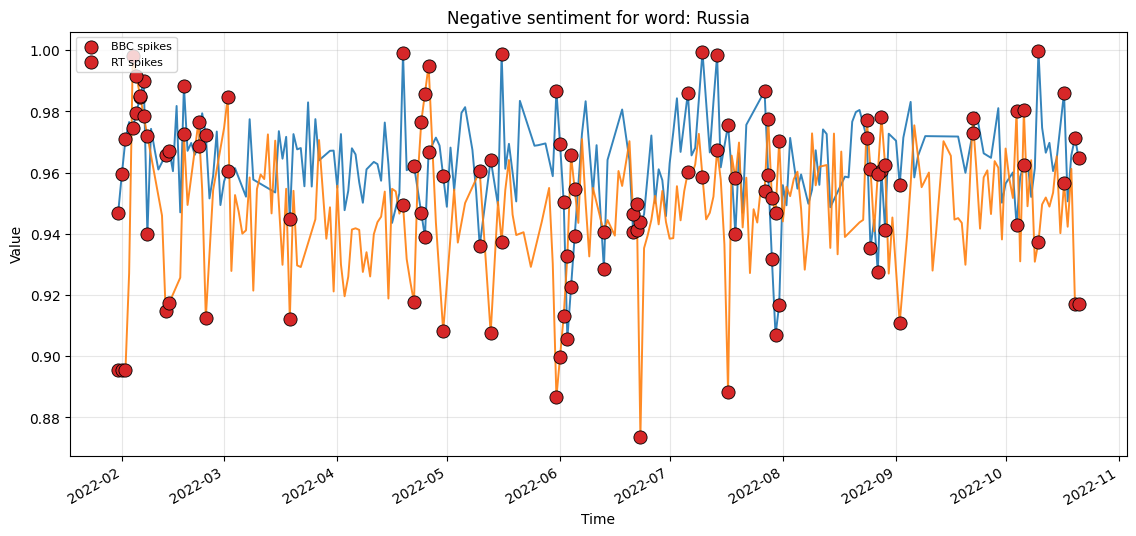

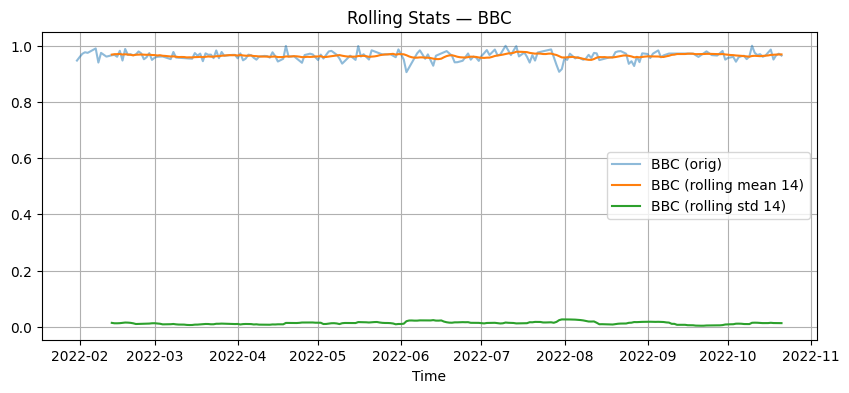

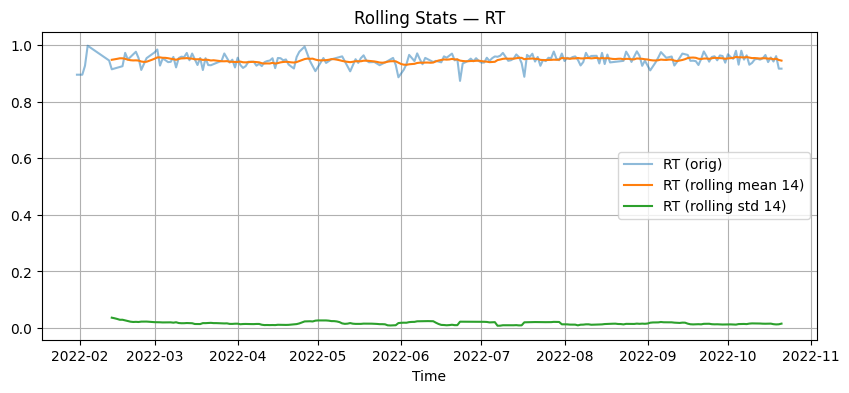

<Figure size 1000x400 with 0 Axes>

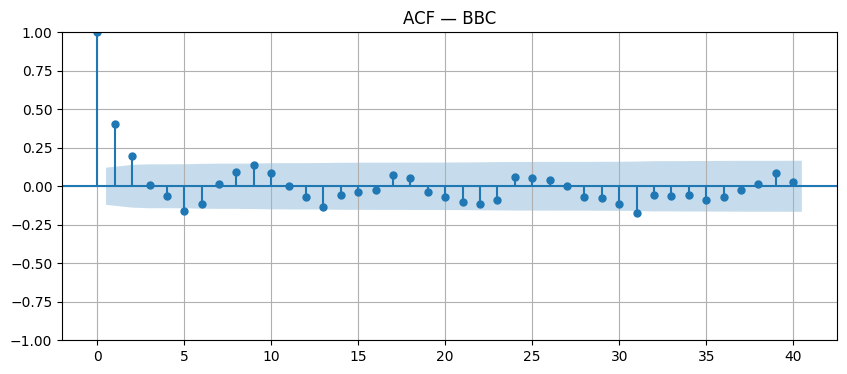

<Figure size 1000x400 with 0 Axes>

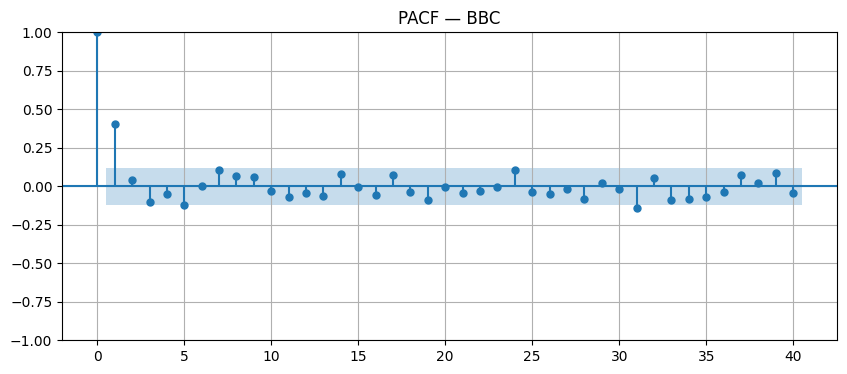

<Figure size 1000x400 with 0 Axes>

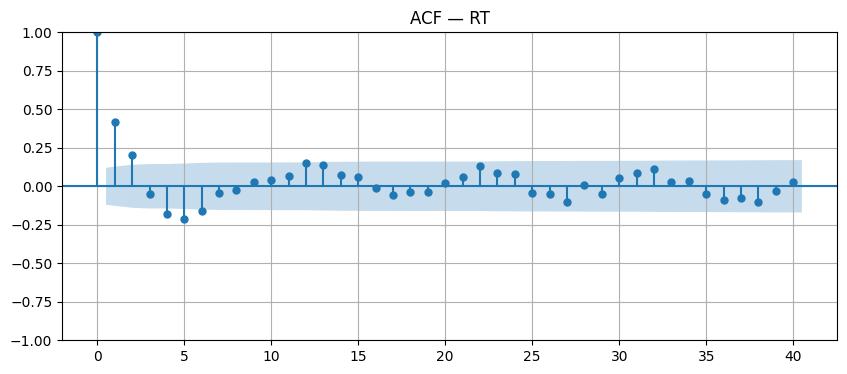

<Figure size 1000x400 with 0 Axes>

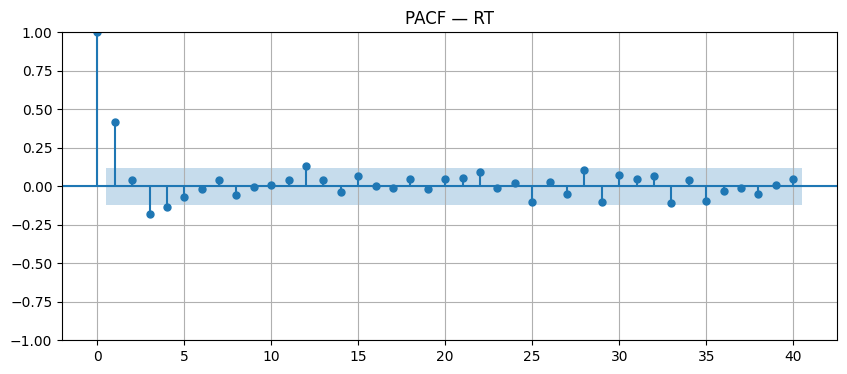

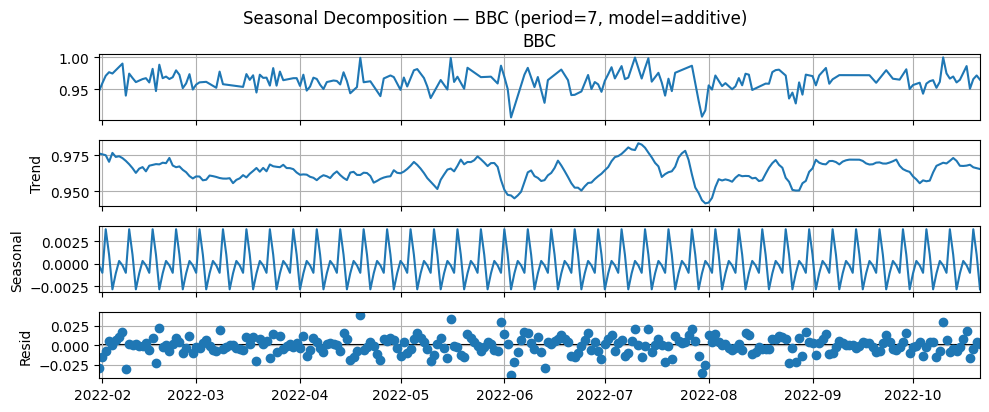

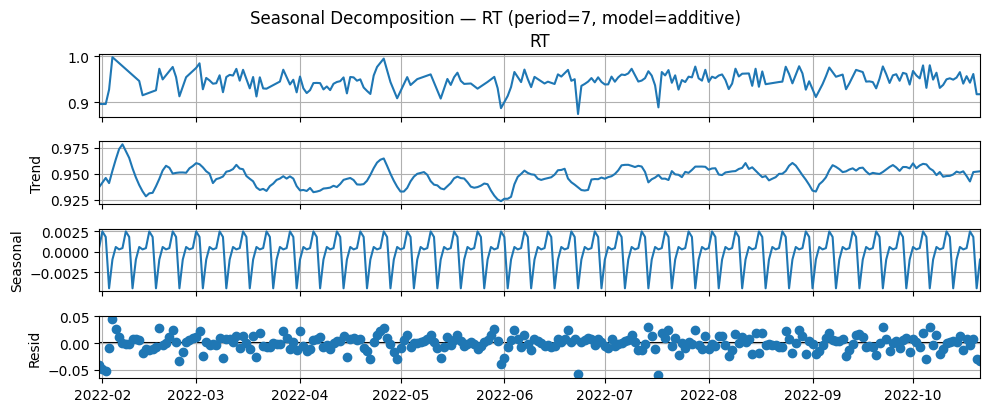

In [ ]:
df, summary = analyze_time_series(
    [list(bbc.index), list(rt.index)],
    [bbc['neutral_sentiment_score'], rt['neutral_sentiment_score']],
    [ 'BBC', 'RT'],
    resample_rule="D",        # or 'H', 'MS', '15min', None
    interpolation="time",     # or 'linear', None
    rolling_window=14,
    do_acf_pacf=True,
    decompose=True,           # set False if you don't want decomposition
    decompose_model="additive",
    decompose_period=7,       # set appropriate period for your cadence
    outlier_z=1.5,
    title="Negative sentiment for word: Russia",
)

In [ ]:
# --- Google Colab Time Series Multi-Series Analysis Utility ---
# If statsmodels is missing in your runtime, uncomment the next line:
# !pip -q install statsmodels

from typing import List, Dict, Optional, Tuple
import textwrap
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


def build_timeseries_df(
    timestamps_list: List[List],
    values_list: List[List[float]],
    labels: List[str],
    *,
    resample_rule: Optional[str] = None,
    interpolation: Optional[str] = "time"
) -> pd.DataFrame:
    """
    Build a single time-indexed DataFrame from multiple series.

    Parameters
    ----------
    timestamps_list : List[List]
        A list where each element is a list of timestamps (str/np.datetime64/datetime).
        Example: [[t1, t2, ...], [t1', t2', ...], ...]
    values_list : List[List[float]]
        A list where each element is a list of numeric values aligned to the corresponding timestamps list.
    labels : List[str]
        Series names (one per series).
    resample_rule : Optional[str]
        Pandas offset alias to resample to (e.g. 'D', 'H', '15min', 'MS').
        If None, no resampling is performed.
    interpolation : Optional[str]
        Interpolation method to fill gaps after outer-join/resample. None to skip.
        Common choices: 'time', 'linear', 'nearest'.

    Returns
    -------
    pd.DataFrame
        A DataFrame with a DateTimeIndex and one column per label.
    """
    if not (len(timestamps_list) == len(values_list) == len(labels)):
        raise ValueError("timestamps_list, values_list, and labels must have the same length.")

    series_frames = []
    for i, (ts, vals, name) in enumerate(zip(timestamps_list, values_list, labels)):
        if len(ts) != len(vals):
            raise ValueError(f"Series '{name}' has {len(ts)} timestamps but {len(vals)} values.")
        s = pd.DataFrame({
            "timestamp": pd.to_datetime(ts, errors="coerce"),
            name: pd.to_numeric(vals, errors="coerce")
        }).dropna(subset=["timestamp"]).set_index("timestamp").sort_index()
        series_frames.append(s)

    # Outer-join on index to keep all timestamps across series.
    df = pd.concat(series_frames, axis=1, join="outer").sort_index()

    # Optional resample to a common grid
    if resample_rule:
        df = df.resample(resample_rule).mean()

    # Optional interpolation
    if interpolation:
        # time-based interpolation requires monotonic datetime index
        df = df.interpolate(method=interpolation, limit_direction="both")

    return df


def quick_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute quick summary stats per series.
    """
    stats = pd.DataFrame({
        "count": df.count(),
        "missing": df.isna().sum(),
        "mean": df.mean(numeric_only=True),
        "std": df.std(numeric_only=True),
        "min": df.min(numeric_only=True),
        "max": df.max(numeric_only=True),
        "start": pd.Series({c: df[c].first_valid_index() for c in df.columns}),
        "end": pd.Series({c: df[c].last_valid_index() for c in df.columns}),
    })
    return stats


def detect_outliers_zscore(df: pd.DataFrame, threshold: float = 3.0) -> Dict[str, pd.DataFrame]:
    """
    Simple z-score outlier detection per series.

    Returns
    -------
    dict: column -> DataFrame with columns ['value', 'zscore'] indexed by outlier timestamps
    """
    outliers = {}
    for col in df.columns:
        s = df[col].dropna()
        if s.empty or s.std() == 0 or math.isnan(s.std()):
            continue
        z = (s - s.mean()) / s.std()
        mask = z.abs() >= threshold
        outliers[col] = pd.DataFrame({"value": s[mask], "zscore": z[mask]})
    return outliers


def bias_detection_table(
    df: pd.DataFrame,
    term: str,
    *,
    site_column: str = "Site",
    entity_column: str = "entity",
    sentiment_column: str = "sentiment",
) -> pd.DataFrame:
    """
    Compute per-site sentiment profiles for a given term to surface potential bias.

    The table compares each site's sentiment for the term against the site's
    overall sentiment baseline.
    """
    missing = [
        col
        for col in (site_column, entity_column, sentiment_column)
        if col not in df.columns
    ]
    if missing:
        raise ValueError(
            f"Missing required columns for bias detection: {', '.join(missing)}"
        )

    working = df[[site_column, entity_column, sentiment_column]].copy()
    working[entity_column] = working[entity_column].astype(str)
    working[sentiment_column] = pd.to_numeric(working[sentiment_column], errors="coerce")
    working = working.dropna(subset=[sentiment_column])
    mask = working[entity_column].str.contains(term, case=False, na=False)
    term_rows = working[mask]
    if term_rows.empty:
        raise ValueError(
            f"No rows matched term '{term}' (case-insensitive substring search)."
        )

    site_stats = (
        working.groupby(site_column)[sentiment_column]
        .agg(site_sentiment_mean="mean", site_sentiment_median="median", site_records="count")
    )
    term_stats = (
        term_rows.groupby(site_column)[sentiment_column]
        .agg(term_sentiment_mean="mean", term_sentiment_median="median", term_mentions="count")
    )

    summary = site_stats.join(term_stats, how="left")
    summary = summary.dropna(subset=["term_sentiment_mean"])
    summary["sentiment_delta"] = summary["term_sentiment_mean"] - summary["site_sentiment_mean"]
    summary["sentiment_ratio"] = summary["term_sentiment_mean"] / summary["site_sentiment_mean"].replace(0, np.nan)
    summary = summary.sort_values("sentiment_delta", ascending=False)
    summary.index.name = site_column
    return summary.reset_index()


def plot_timeseries_original(df: pd.DataFrame, labels: Optional[List[str]] = None, title: str = "Time Series", events_df: Optional[pd.DataFrame] = None, spike_dates: Optional[pd.DatetimeIndex] = None):
    """
    Line plot of all series on the same axes.
    """
    ax = df[labels] if labels else df
    ax.plot()
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")

    if events_df is not None and 'date' in events_df.columns and 'event_summary' in events_df.columns:
        events_df['date'] = pd.to_datetime(events_df['date'], errors='coerce')
        # Filter events to only include those on spike dates if spike_dates is provided
        if spike_dates is not None:
            events_df = events_df[events_df['date'].isin(spike_dates)]

        # Sort events by date to help with positioning
        events_df = events_df.sort_values('date')

        y_offset = 0.05 # Initial vertical offset
        offset_increment = 0.10 # Increment for each subsequent label at the same x-position

        for index, row in events_df.dropna(subset=['date']).iterrows():
            plt.axvline(x=row['date'], color='r', linestyle='--', alpha=0.5)
            # Adjust vertical position based on the number of annotations at this date
            current_offset = y_offset + events_df.loc[events_df['date'] == row['date']].index.get_loc(index) * offset_increment
            plt.text(row['date'], plt.ylim()[1] - (plt.ylim()[1] - plt.ylim()[0]) * current_offset, row['event_summary'])

    plt.show()


def plot_rolling(df: pd.DataFrame, window: int = 12):
    """
    Plot rolling mean and std per series.
    """
    for col in df.columns:
        s = df[col].dropna()
        if len(s) < window:
            continue
        roll_mean = s.rolling(window).mean()
        roll_std = s.rolling(window).std()
        plt.plot(s, label=f"{col} (orig)", alpha=0.5)
        plt.plot(roll_mean, label=f"{col} (rolling mean {window})")
        plt.plot(roll_std, label=f"{col} (rolling std {window})")
        plt.title(f"Rolling Stats — {col}")
        plt.xlabel("Time")
        plt.legend(loc="best")
        plt.show()


def plot_acf_pacf_for_each(df: pd.DataFrame, lags: int = 40):
    """
    Plot ACF and PACF for each series separately.
    """
    for col in df.columns:
        s = df[col].dropna()
        if len(s) < 10:
            continue
        plt.figure()
        plot_acf(s, lags=min(lags, len(s)//2 - 1), title=f"ACF — {col}")
        plt.show()

        plt.figure()
        plot_pacf(s, lags=min(lags, len(s)//2 - 1), title=f"PACF — {col}", method="ywm")
        plt.show()


def try_seasonal_decompose(df: pd.DataFrame, model: str = "additive", period: Optional[int] = None):
    """
    Attempt seasonal decomposition for each series; skip if insufficient data.

    Parameters
    ----------
    model : 'additive' or 'multiplicative'
    period : Optional[int]
        If None, tries to infer by index frequency (e.g., 12 for monthly, 7 for daily weekly seasonality, etc.).
    """
    # Attempt to infer a period from index frequency if not provided
    inferred = pd.infer_freq(df.index)
    inferred_period = None
    if inferred is not None:
        # crude mapping for common alias -> period
        # If you know your seasonality, pass 'period' explicitly (e.g., 12 for monthly data).
        alias_to_period = {
            "A": None, "Y": None,
            "Q": None,
            "M": 12,
            "W": 52,
            "D": 7,     # weekly pattern in daily data (adjust if needed)
            "H": 24,    # daily pattern in hourly data
            "T": 60,    # hourly pattern in minutely data
            "min": 60
        }
        # Use the first letter (or exact) to guess
        key = inferred
        key_short = inferred[0] if inferred else None
        inferred_period = alias_to_period.get(key, alias_to_period.get(key_short, None))

    use_period = period if period is not None else inferred_period

    for col in df.columns:
        s = df[col].dropna()
        if use_period is None or len(s) < (use_period or 2) * 2:
            # Not enough data or no period; skip
            continue
        try:
            result = seasonal_decompose(s, model=model, period=use_period, extrapolate_trend="freq")
            result.plot()
            plt.suptitle(f"Seasonal Decomposition — {col} (period={use_period}, model={model})", y=1.02)
            plt.show()
        except Exception as e:
            print(f"[Decompose skipped for {col}] {e}")

def plot_timeseries(
    df: pd.DataFrame,
    labels: Optional[List[str]] = None,
    title: str = "Time Series",
    events_df: Optional[pd.DataFrame] = None,
    spike_dates: Optional[pd.DatetimeIndex] = None,
):
    """
    Line plot of all series on the same axes, with event labels positioned
    near the local spike (max across series) closest to each event date.
    """

    # ✅ ALWAYS get the matplotlib Axes object
    cols = labels if labels else list(df.columns)
    ax = df[cols].plot()   # <--- THIS is important!
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")

    if events_df is not None and 'date' in events_df.columns and 'event_summary' in events_df.columns:
        # Copy & clean
        events = events_df.copy()
        events['date'] = pd.to_datetime(events['date'], errors='coerce')
        events = events.dropna(subset=['date', 'event_summary']).sort_values('date')

        # Filter to spike dates if provided
        if spike_dates is not None and len(spike_dates) > 0:
            spike_dates = pd.to_datetime(spike_dates)
            events = events[events['date'].isin(spike_dates)]

        numeric_df = df[cols].copy()
        for c in numeric_df.columns:
            numeric_df[c] = pd.to_numeric(numeric_df[c], errors='coerce')

        def y_at_nearest(ts: pd.Timestamp):
            if numeric_df.empty:
                return None
            pos = numeric_df.index.get_indexer([ts], method='nearest')
            if len(pos) == 0 or pos[0] == -1:
                return None
            val = numeric_df.iloc[pos[0]].max(skipna=True)
            return val if np.isfinite(val) else None

        used_positions: List[Tuple[pd.Timestamp, int, int]] = []
        offsets = [
            (0, 24),
            (26, 24),
            (-26, 24),
            (0, -30),
            (32, -30),
            (-32, -30),
            (14, 40),
            (-14, 40),
            (20, -46),
            (-20, -46),
        ]
        label_idx = 0
        per_date_counts: Dict[pd.Timestamp, int] = {}

        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min if y_max > y_min else 1.0
        fallback_y = y_min + 0.8 * y_range

        for _, row in events.iterrows():
            edate = row['date']
            etext = str(row['event_summary']).strip()
            if not etext:
                continue

            y_target = y_at_nearest(edate)
            if y_target is None:
                y_target = fallback_y

            ax.axvline(
                x=edate,
                color='#d62728',
                linestyle='--',
                alpha=0.25,
                linewidth=0.8,
                zorder=1,
            )

            base_dx, base_dy = offsets[label_idx % len(offsets)]
            cycle = label_idx // len(offsets)
            bump = cycle * 16
            dy = base_dy + (bump if base_dy > 0 else -bump)
            dx = base_dx
            if dy == 0:
                dy = 20

            count_for_date = per_date_counts.get(edate, 0)
            per_date_counts[edate] = count_for_date + 1
            vertical_direction = 1 if count_for_date % 2 == 0 else -1
            vertical_steps = (count_for_date // 2) + 1
            dy += vertical_direction * vertical_steps * 38

            step = 16 if dy > 0 else -16
            attempts = 0
            while any(
                (
                    abs((edate - prev_date).days) <= 1
                    and abs(dx - prev_dx) < 22
                    and abs(dy - prev_dy) < 20
                )
                for prev_date, prev_dx, prev_dy in used_positions
            ):
                if attempts % 2 == 0:
                    dy += step
                else:
                    if dx == 0:
                        dx = 28 if vertical_direction > 0 else -28
                    else:
                        dx += 24 if dx > 0 else -24
                attempts += 1
                if attempts > 12:
                    break
            used_positions.append((edate, dx, dy))

            ha = "center"
            if dx > 0:
                ha = "left"
            elif dx < 0:
                ha = "right"
            va = "bottom" if dy > 0 else "top"

            wrapped_text = "\n".join(textwrap.wrap(etext, width=40)) if len(etext) > 50 else etext

            ax.annotate(
                wrapped_text,
                xy=(edate, y_target),
                xytext=(dx, dy),
                textcoords="offset points",
                ha=ha,
                va=va,
                fontsize=8,
                color="#d62728",
                linespacing=1.3,
                bbox={
                    "boxstyle": "round,pad=0.2",
                    "fc": "white",
                    "ec": "#d62728",
                    "lw": 0.6,
                    "alpha": 0.95,
                },
                arrowprops={
                    "arrowstyle": "-",
                    "color": "#d62728",
                    "lw": 0.6,
                },
                zorder=6,
            )
            label_idx += 1

    plt.show()

def analyze_time_series(
    timestamps_list: List[List],
    values_list: List[List[float]],
    labels: List[str],
    *,
    resample_rule: Optional[str] = None,
    interpolation: Optional[str] = "time",
    rolling_window: int = 12,
    do_acf_pacf: bool = True,
    decompose: bool = False,
    decompose_model: str = "additive",
    decompose_period: Optional[int] = None,
    outlier_z: float = 3.0,
    events_df: Optional[pd.DataFrame] = None,
    title: Optional[str] = None,
    bias_term: Optional[str] = None,
    bias_source_df: Optional[pd.DataFrame] = None,
    bias_site_column: str = "Site",
    bias_entity_column: str = "entity",
    bias_sentiment_column: str = "sentiment",
) -> Tuple[pd.DataFrame, Dict]:
    """
    End-to-end analysis: build DF, compute stats, plot, and return results.

    Returns
    -------
    (df, summary)
      df: consolidated DataFrame
      summary: dict with 'stats' (DataFrame) and 'outliers' (dict of DataFrames)
    """
    df = build_timeseries_df(
        timestamps_list, values_list, labels,
        resample_rule=resample_rule, interpolation=interpolation
    )

    # Basic overview
    print("▶ DataFrame shape:", df.shape)
    print("▶ Date range:", df.index.min(), "→", df.index.max())
    print("▶ Head:")
    display(df.head())

    # Quick stats
    stats_df = quick_stats(df)
    print("▶ Quick stats:")
    display(stats_df)

    # Outliers
    outliers = detect_outliers_zscore(df, threshold=outlier_z)
    total_outliers = sum(len(v) for v in outliers.values())
    print(f"▶ Outliers detected (|z| ≥ {outlier_z}): {total_outliers} across {len(outliers)} series.")

    # Get spike dates from outliers
    spike_dates = pd.DatetimeIndex([])
    for col in outliers:
      spike_dates = spike_dates.union(outliers[col].index)


    # Plots
    plot_timeseries(df, title=title or "All Series", events_df=events_df, spike_dates=spike_dates)
    if rolling_window and rolling_window > 1:
        plot_rolling(df, window=rolling_window)
    if do_acf_pacf:
        plot_acf_pacf_for_each(df)
    if decompose:
        try_seasonal_decompose(df, model=decompose_model, period=decompose_period)

    bias_summary = None
    if bias_term:
        if bias_source_df is None:
            print("[Bias detection skipped] Provide 'bias_source_df' with Site/entity data.")
        else:
            try:
                bias_summary = bias_detection_table(
                    bias_source_df,
                    bias_term,
                    site_column=bias_site_column,
                    entity_column=bias_entity_column,
                    sentiment_column=bias_sentiment_column,
                )
                print(f"▶ Bias detection for term '{bias_term}':")
                try:
                    display(bias_summary)
                except NameError:
                    print(bias_summary.to_string(index=False))
            except ValueError as exc:
                print(f"[Bias detection skipped] {exc}")

    return df, {"stats": stats_df, "outliers": outliers, "bias": bias_summary}


In [ ]:
bias_detection_table(sentiment, 'putin', sentiment_column='negative_sentiment_score')

,Site,site_sentiment_mean,site_sentiment_median,site_records,term_sentiment_mean,term_sentiment_median,term_mentions,sentiment_delta,sentiment_ratio
0,tass.com,0.016874,0.000001,1673,0.333113,0.000000,3,0.316239,19.741283
1,www.msnbc.com,0.031090,0.000001,195488,0.261014,0.004300,1473,0.229924,8.395550
2,censor.net,0.027028,0.000002,260649,0.253873,0.000111,440,0.226845,9.392832
3,bbc.co.uk,0.031369,0.000001,87900,0.254693,0.000098,539,0.223325,8.119360
4,en.news-front.info,0.050326,0.000001,7551,0.227999,0.000000,15,0.177673,4.530467
5,aljazeera.com,0.028615,0.000001,151524,0.199200,0.000079,975,0.170585,6.961455
6,reuters.com,0.031291,0.000001,154484,0.161466,0.000008,943,0.130175,5.160138
7,rt.com,0.044857,0.000001,84798,0.148700,0.000001,275,0.103842,3.314949
8,ukrinform.net,0.027773,0.000001,384654,0.114417,0.000000,1874,0.086644,4.119677


In [ ]:
import pandas as pd
import numpy as np

def top_entities_by_sentiment(df,
                              site_col='Site',
                              sentiment_col='sentiment',
                              entity_type_col='entity_type',
                              entity_col='entity',
                              top_n=10,
                              site_filter=None,
                              entity_type_filter=None,
                              weighted=True):
    """
    Compute and return top N entities ranked by average sentiment
    and (optionally) weighted by mention frequency.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing sentiment data.
    site_col : str
        Column name for site (default: 'Site').
    sentiment_col : str
        Column name for sentiment score (default: 'sentiment').
    entity_type_col : str
        Column name for entity type (default: 'entity_type').
    entity_col : str
        Column name for entity name (default: 'entity').
    top_n : int
        Number of top entities to return (default: 10).
    site_filter : str or list, optional
        Filter for specific site(s). If None, include all.
    entity_type_filter : str or list, optional
        Filter for specific entity type(s). If None, include all.
    weighted : bool
        Whether to include a weighted score based on mention frequency (default: True).

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        [entity, entity_type, avg_sentiment, mention_count, weighted_score]
        sorted by weighted_score (if weighted=True) or avg_sentiment.
    """

    df_filtered = df.copy()

    # Apply filters if provided
    if site_filter is not None:
        df_filtered = df_filtered[df_filtered[site_col].isin([site_filter] if isinstance(site_filter, str) else site_filter)]

    if entity_type_filter is not None:
        df_filtered = df_filtered[df_filtered[entity_type_col].isin([entity_type_filter] if isinstance(entity_type_filter, str) else entity_type_filter)]

    # Group by entity and entity type
    grouped = (
        df_filtered
        .groupby([entity_col, entity_type_col])[sentiment_col]
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'avg_sentiment', 'count': 'mention_count'})
        .reset_index()
    )

    # Add weighted score (optional)
    if weighted:
        grouped['weighted_score'] = grouped['avg_sentiment'] * np.log1p(grouped['mention_count'])
        sort_col = 'weighted_score'
    else:
        sort_col = 'avg_sentiment'

    # Sort and select top N
    ranked = grouped.sort_values(sort_col, ascending=False).head(top_n).reset_index(drop=True)

    # Add ranking column
    ranked.insert(0, 'rank', ranked.index + 1)

    return ranked


In [ ]:
sentiment['entity_type'].unique()

array(['QUANTITY', 'LOCATION', 'DATE', 'OTHER', 'ORGANIZATION', 'PERSON',
       'FACILITY', 'SOFTWARE', 'MOVIE', 'EVENT', 'PERSONAL_TITLE',
       'BRAND', 'ATTRIBUTE', 'BOOK', 'COMMERCIAL_ITEM', 'GAME', 'MUSIC'],
      dtype=object)

In [ ]:
top_entities_by_sentiment(sentiment, sentiment_col="mixed_sentiment_score", entity_type_filter="PERSON")

,rank,entity,entity_type,avg_sentiment,mention_count,weighted_score
0,1,Force,PERSON,0.306939,1,0.212754
1,2,Bus,PERSON,0.259558,1,0.179912
2,3,you`re MELBER MELBER,PERSON,0.117166,1,0.081213
3,4,Orchestra,PERSON,0.051749,2,0.056852
4,5,guards guards,PERSON,0.020909,7,0.043479
5,6,Leader,PERSON,0.021875,6,0.042566
6,7,Farrow,PERSON,0.037298,2,0.040976
7,8,of the,PERSON,0.054566,1,0.037822
8,9,Jolie,PERSON,0.033746,2,0.037074
9,10,staff joint,PERSON,0.048612,1,0.033695


In [ ]:
import pandas as pd

def sentiment_table_by_entity(df, entity_name,
                              entity_col='entity',
                              site_col='Site',
                              positive_col='positive_sentiment_score',
                              negative_col='negative_sentiment_score',
                              mixed_col='mixed_sentiment_score',
                              neutral_col='neutral_sentiment_score'):
    """
    Create a table showing average sentiment scores per site for a given entity.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing sentiment scores for entities across sites.
    entity_name : str
        Entity name (or partial string) to filter.
    entity_col, site_col : str
        Column names for entity and site.
    *_col : str
        Column names for sentiment types.

    Returns
    -------
    pd.DataFrame
        Pivot-like table where each row = Site, each column = sentiment type.
    """

    # Filter for the entity (case-insensitive, partial match allowed)
    mask = df[entity_col].str.contains(entity_name, case=False, na=False)
    filtered = df.loc[mask]

    if filtered.empty:
        raise ValueError(f"No entries found for entity '{entity_name}'")

    # Group by site and compute average sentiment scores
    summary = (
        filtered.groupby(site_col)[[positive_col, negative_col, mixed_col, neutral_col]]
        .mean()
        .round(3)
        .reset_index()
        .sort_values(positive_col, ascending=False)
    )

    return summary


In [ ]:
sentiment_table_by_entity(sentiment, 'zelensky').to_csv()


',Site,positive_sentiment_score,negative_sentiment_score,mixed_sentiment_score,neutral_sentiment_score\n3,en.news-front.info,0.026,0.168,0.0,0.806\n8,www.msnbc.com,0.017,0.044,0.0,0.939\n2,censor.net,0.008,0.038,0.0,0.955\n7,ukrinform.net,0.007,0.015,0.0,0.977\n5,rt.com,0.006,0.128,0.0,0.865\n1,bbc.co.uk,0.005,0.014,0.0,0.981\n0,aljazeera.com,0.004,0.037,0.0,0.959\n4,reuters.com,0.0,0.009,0.0,0.991\n6,tass.com,0.0,0.008,0.0,0.992\n'